In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Notice the quotes around the Drive path to handle the spaces!
!cp "/content/drive/MyDrive/DLCVProjectCode/DLCV_Project_Code.zip" /content/
!unzip -q -o /content/DLCV_Project_Code.zip -d /content/workspace
%cd /content/workspace

Mounted at /content/drive
/content/workspace


In [4]:
%cd /content/workspace/NeuroScan---Explainable-Brain-Tumour-Classification-required-changes

/content/workspace/NeuroScan---Explainable-Brain-Tumour-Classification-required-changes


In [5]:
import json
import os

# ---> PASTE YOUR KAGGLE INFO HERE <---
# SECURITY: never hardcode Kaggle keys in notebooks.
# Upload `kaggle.json` to Colab (/content/kaggle.json) and this cell will install it.

assert os.path.exists('/content/kaggle.json'), "Upload kaggle.json to /content first"

!mkdir -p /root/.kaggle
!cp /content/kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

# (Optional) verify
!ls -la /root/.kaggle

# Kaggle config is already installed above from /content/kaggle.json

# 4. Download and unzip using the exact name from your URL
!mkdir -p data
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset -p data
!cd data && unzip -q -o brain-tumor-mri-dataset.zip && cd ..

# 5. Install dependencies
!pip install -r requirements.txt

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:00<00:00, 242MB/s]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 91.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 37.2 MB/s eta 0:00:00


In [ ]:
%cd /content/workspace/NeuroScan---Explainable-Brain-Tumour-Classification-required-changes

/content/workspace/NeuroScan---Explainable-Brain-Tumour-Classification-required-changes


In [6]:
!echo "=== STARTING EFFICIENTNET BASELINE: $(date) ==="
!python train.py --model efficientnet_b0 --epochs 30 --num_workers 0 --batch_size 64

!echo "=== STARTING EFFICIENTNET SAM: $(date) ==="
!python train.py --model efficientnet_b0 --use_sam --rho 0.05 --epochs 30 --num_workers 0 --batch_size 64

!echo "=== STARTING RESNET-50: $(date) ==="
!python train.py --model resnet50 --epochs 30 --num_workers 0 --batch_size 64

!echo "=== ALL TRAINING FINISHED: $(date) ==="

=== STARTING EFFICIENTNET BASELINE: Tue May  5 07:00:29 PM UTC 2026 ===
Using device: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100% 20.5M/20.5M [00:00<00:00, 153MB/s]
Epoch 1/30  train_loss=0.4969  val_macro_f1=0.8835  val_acc=0.8852  val_auroc=0.9727
  -> saved /content/workspace/NeuroScan---Explainable-Brain-Tumour-Classification-required-changes/outputs/checkpoints/best_efficientnet_b0_baseline.pt
Epoch 2/30  train_loss=0.2317  val_macro_f1=0.9242  val_acc=0.9250  val_auroc=0.9898
  -> saved /content/workspace/NeuroScan---Explainable-Brain-Tumour-Classification-required-changes/outputs/checkpoints/best_efficientnet_b0_baseline.pt
Epoch 3/30  train_loss=0.1675  val_macro_f1=0.9441  val_acc=0.9444  val_auroc=0.9963
  -> saved /content/workspace/NeuroScan---Explainable-Brain-Tumour-Classification-required-changes/outputs/checkpoints/best_efficientnet_b0_bas

In [ ]:
!pwd

/content/workspace/NeuroScan---Explainable-Brain-Tumour-Classification-required-changes


In [ ]:
# Saving back to the new folder with quotes
!cp -r /content/workspace/NeuroScan---Explainable-Brain-Tumour-Classification-required-changes/outputs/checkpoints "/content/drive/MyDrive/DLCVProjectCode/"

In [7]:
# 1. Evaluate EfficientNet Baseline
!python eval.py --checkpoint outputs/checkpoints/best_efficientnet_b0_baseline.pt --output_dir outputs/results/baseline

# 2. Evaluate EfficientNet SAM
!python eval.py --checkpoint outputs/checkpoints/best_efficientnet_b0_sam.pt --output_dir outputs/results/sam

# 3. Evaluate ResNet-50
!python eval.py --checkpoint outputs/checkpoints/best_resnet50_baseline.pt --output_dir outputs/results/resnet50

Using device: cuda
Saved outputs/results/baseline/metrics_best_efficientnet_b0_baseline.json
Test results:
  Accuracy:       0.9889
  Macro-F1:       0.9889
  Macro-Precision:0.9889
  Macro-Recall:   0.9889
  AUROC:          0.9970
Confusion matrix:
[[263   6   1   0]
 [  1 267   0   2]
 [  1   0 268   1]
 [  0   0   0 270]]
Saved outputs/results/baseline/metrics_best_efficientnet_b0_baseline.md
Using device: cuda
Saved outputs/results/sam/metrics_best_efficientnet_b0_sam.json
Test results:
  Accuracy:       0.9843
  Macro-F1:       0.9842
  Macro-Precision:0.9844
  Macro-Recall:   0.9843
  AUROC:          0.9986
Confusion matrix:
[[260   9   1   0]
 [  1 266   0   3]
 [  1   0 267   2]
 [  0   0   0 270]]
Saved outputs/results/sam/metrics_best_efficientnet_b0_sam.md
Using device: cuda
Saved outputs/results/resnet50/metrics_best_resnet50_baseline.json
Test results:
  Accuracy:       0.9861
  Macro-F1:       0.9861
  Macro-Precision:0.9864
  Macro-Recall:   0.9861
  AUROC:          0.99

In [ ]:
!ls -R /content/workspace

Streaming output truncated to the last 5000 lines.
attr.h		    embed.h		  pybind11.h
buffer_info.h	    eval.h		  pytypes.h
cast.h		    functional.h	  stl
chrono.h	    gil.h		  stl_bind.h
common.h	    gil_safe_call_once.h  stl.h
complex.h	    gil_simple.h	  subinterpreter.h
conduit		    iostream.h		  trampoline_self_life_support.h
critical_section.h  native_enum.h	  type_caster_pyobject_ptr.h
detail		    numpy.h		  typing.h
eigen		    operators.h		  warnings.h
eigen.h		    options.h

/content/workspace/NeuroScan---Explainable-Brain-Tumour-Classification/venv/lib/python3.13/site-packages/torch/include/pybind11/conduit:
pybind11_conduit_v1.h  pybind11_platform_abi_id.h  wrap_include_python_h.h

/content/workspace/NeuroScan---Explainable-Brain-Tumour-Classification/venv/lib/python3.13/site-packages/torch/include/pybind11/detail:
class.h				    internals.h
common.h			    native_enum_data.h
cpp_conduit.h			    pybind11_namespace_macros.h
descr.h				    struct_smart_holder.h
dynamic_raw_ptr_c

In [ ]:
!pwd

/content/workspace/NeuroScan---Explainable-Brain-Tumour-Classification-required-changes


In [8]:
import os
import sys

# Add the current directory to the path so it can find the explainability module
os.environ['PYTHONPATH'] = "/content/workspace:" + os.environ.get('PYTHONPATH', '')

# Now run the explainability script
!python explain.py --checkpoint outputs/checkpoints/best_efficientnet_b0_sam.pt --output_dir outputs/results/explainability

Using device: cuda
Explain:   0% 0/8 [00:00<?, ?it/s]Saved outputs/results/explainability/explainability/explain_00_true_glioma_pred_glioma.png
Explain:  12% 1/8 [00:02<00:19,  2.76s/it]Saved outputs/results/explainability/explainability/explain_01_true_glioma_pred_glioma.png
Explain:  25% 2/8 [00:04<00:13,  2.18s/it]Saved outputs/results/explainability/explainability/explain_02_true_meningioma_pred_meningioma.png
Explain:  38% 3/8 [00:06<00:09,  1.99s/it]Saved outputs/results/explainability/explainability/explain_03_true_meningioma_pred_meningioma.png
Explain:  50% 4/8 [00:08<00:07,  1.93s/it]Saved outputs/results/explainability/explainability/explain_04_true_notumor_pred_notumor.png
Explain:  62% 5/8 [00:09<00:05,  1.89s/it]Saved outputs/results/explainability/explainability/explain_05_true_notumor_pred_notumor.png
Explain:  75% 6/8 [00:11<00:03,  1.86s/it]Saved outputs/results/explainability/explainability/explain_06_true_pituitary_pred_pituitary.png
Explain:  88% 7/8 [00:14<00:02, 

In [9]:
# Sync both checkpoints and result visualizations
!cp -r /content/workspace/NeuroScan---Explainable-Brain-Tumour-Classification-required-changes/outputs/checkpoints "/content/drive/MyDrive/DLCVProjectCode/"
!cp -r /content/workspace/NeuroScan---Explainable-Brain-Tumour-Classification-required-changes/outputs/results "/content/drive/MyDrive/DLCVProjectCode/"
!echo "=== ALL FILES SECURED TO DRIVE: $(date) ==="

=== ALL FILES SECURED TO DRIVE: Tue May  5 09:26:05 PM UTC 2026 ===


### Sharpness-Aware Minimization (SAM)

As discussed, the concept of "sharpness awareness" during training, which aims to find flatter minima for better generalization, is already incorporated into the training process through the Sharpness-Aware Minimization (SAM) optimizer. One of the training runs executed previously (`efficientnet_b0` with `use_sam`) used this technique. SAM explicitly encourages the model to converge to regions of the loss landscape that are flatter, thereby making the training process 'sharpness-aware' as a loss function.

### Visualizing Raw Activations

Beyond Grad-CAM, visualizing raw activations from the last convolutional layer can also provide insights into what the model 'sees.' These activations are direct outputs of the features learned by the network. Let's load a trained model and visualize the raw activations for a sample image.

In [16]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os
import sys

# Add the current working directory to sys.path to ensure local modules are found
sys.path.append(os.getcwd())

# Assuming the current working directory is still: /content/workspace/NeuroScan---Explainable-Brain-Tumour-Classification-required-changes
# Define path to the best SAM model checkpoint
checkpoint_path = 'outputs/checkpoints/best_efficientnet_b0_sam.pt'

# Load the model directly (assuming models.py and config.py are accessible)
# This requires importing necessary components from the project structure
from models import build_model
from config import NUM_CLASSES # Import NUM_CLASSES instead of model_configs

# Get model configuration for efficientnet_b0
model_name = 'efficientnet_b0'
num_classes = NUM_CLASSES # Use the imported NUM_CLASSES directly
model = build_model(model_name, num_classes=num_classes, pretrained=False)

# Load state dict
# The checkpoint is a dictionary, so we need to access the 'model_state_dict' key
checkpoint = torch.load(checkpoint_path, map_location=torch.device('cpu'))
model.load_state_dict(checkpoint['model_state_dict'])
model.eval() # Set model to evaluation mode
print(f"Loaded model from {checkpoint_path}")

Loaded model from outputs/checkpoints/best_efficientnet_b0_sam.pt


In [14]:
# Display the content of config.py to identify the correct configuration variable
!cat config.py

"""
Configuration for Brain Tumor Classification with SAM.
Central place for paths, hyperparameters, and data settings.
"""
import os
from pathlib import Path

# ---------- Paths ----------
PROJECT_ROOT = Path(__file__).resolve().parent
DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
CHECKPOINTS_DIR = OUTPUTS_DIR / "checkpoints"
RESULTS_DIR = OUTPUTS_DIR / "results"
MONITORING_DIR = OUTPUTS_DIR / "monitoring"
GRADCAM_DIR = MONITORING_DIR / "gradcam_epochs"
HISTORY_PATH = MONITORING_DIR / "training_history.jsonl"

# Expected data layout after download: data/Brain Tumor MRI Dataset/<class_name>/*.jpg
# Or: data/<class_name>/*.jpg depending on Kaggle extract structure
DATASET_SUBDIR = "Brain Tumor MRI Dataset"  # subfolder name inside data/ if present
CLASS_NAMES = ["glioma", "meningioma", "notumor", "pituitary"]  # folder names, order = label 0,1,2,3

# ---------- Data ----------
IMG_SIZE = 224
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
RANDOM_STATE = 4

In [12]:
# Display the content of models.py to verify the function name
!cat models.py

"""
EfficientNet-B0 and ResNet-50 with 4-class head: GAP -> Dropout(0.5) -> Linear(4).
Pretrained on ImageNet; grayscale MRIs are replicated to 3ch in the data pipeline.
"""
import torch
import torch.nn as nn
from torchvision import models
from typing import Optional

NUM_CLASSES = 4
DROPOUT_P = 0.5


def _replace_classifier(module: nn.Module, in_features: int, num_classes: int = NUM_CLASSES) -> None:
    module.classifier = nn.Sequential(
        nn.AdaptiveAvgPool2d(1),
        nn.Flatten(),
        nn.Dropout(p=DROPOUT_P),
        nn.Linear(in_features, num_classes),
    )


def efficientnet_b0(pretrained: bool = True, num_classes: int = NUM_CLASSES) -> nn.Module:
    """EfficientNet-B0 with 4-class head. Model already has avgpool+flatten before classifier."""
    m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None)
    # torchvision EfficientNet: forward does features -> avgpool -> flatten -> classifier; classifier is (Dropout, Li

Selected sample image from test set with true label: 1


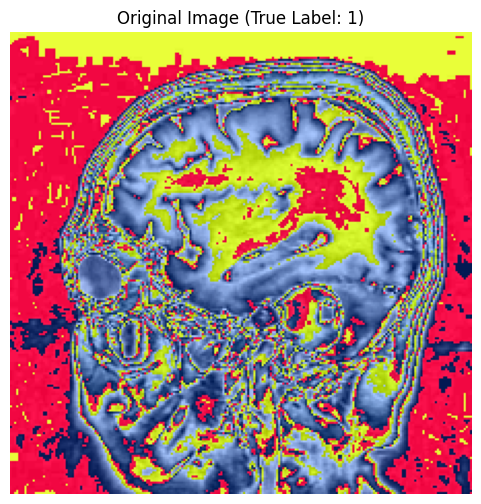

In [22]:
from dataset import build_dataloaders, BrainTumorDataset # Import build_dataloaders and BrainTumorDataset
from torch.utils.data import DataLoader
from pathlib import Path # Import Path for path handling

# Get the test dataset to sample an image
# Call build_dataloaders to get train, val, and test loaders
train_loader, val_loader, test_loader = build_dataloaders(data_root=Path('./data'))

# Extract the test_dataset from the test_loader
test_dataset = test_loader.dataset

# Select a sample image from the test set
sample_idx = 0 # You can change this index to view different images
sample_image, sample_label = test_dataset[sample_idx]

# Get class names from the dataset (assuming it has a classes attribute)
class_names = test_dataset.classes if hasattr(test_dataset, 'classes') else [str(i) for i in range(num_classes)]
true_label_name = class_names[sample_label]

# Preprocessing for visualization (ensure it's compatible with model's expected input)
preprocess = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Apply preprocessing to the original PIL image (assuming sample_image is PIL Image from dataset)
# If sample_image is already a tensor, you might need to convert it back or adjust preprocess
# For simplicity, let's assume the dataset returns PIL Image
# If `sample_image` is already a Tensor, skip transforms.ToPILImage() and resize/crop manually if needed.

# To ensure we have a PIL Image for consistent preprocessing
if isinstance(sample_image, torch.Tensor):
    # Convert tensor to PIL Image if it's already a tensor
    img_vis = transforms.ToPILImage()(sample_image)
else:
    img_vis = sample_image

input_tensor = preprocess(img_vis).unsqueeze(0) # Add batch dimension

print(f"Selected sample image from test set with true label: {true_label_name}")

# Display the original image
plt.figure(figsize=(6, 6))
plt.imshow(img_vis)
plt.title(f"Original Image (True Label: {true_label_name})")
plt.axis('off')
plt.show()

In [21]:
!ls -l ./data/

total 160820
-rw-r--r-- 1 root root 164670110 Feb 13 19:26 brain-tumor-mri-dataset.zip
drwxr-xr-x 6 root root      4096 May  5 18:56 Testing
drwxr-xr-x 6 root root      4096 May  5 18:56 Training


In [18]:
!cat dataset.py

"""
Custom PyTorch Dataset and 70/15/15 split for Brain Tumor MRI.
Class mapping: glioma=0, meningioma=1, notumor=2, pituitary=3.
"""
import os
from pathlib import Path
from typing import Optional, Tuple, List

import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.model_selection import train_test_split

import config
from transforms import get_train_transforms, get_val_test_transforms


def find_class_dirs(root: Path, class_names: List[str]) -> Tuple[Path, List[str]]:
    """Locate dataset root and which class dirs exist. Returns (data_root, present_classes)."""
    candidate = root / config.DATASET_SUBDIR
    if candidate.exists():
        root = candidate
    present = []
    for c in class_names:
        if (root / c).exists() or (root / "Training" / c).exists() or (root / "Testing" / c).exists():
            present.append(c)
    if not present:
        for name in os.listdir(root):
            d = root / name
            if d.is_dir() an

Using last convolutional layer: features.8.0


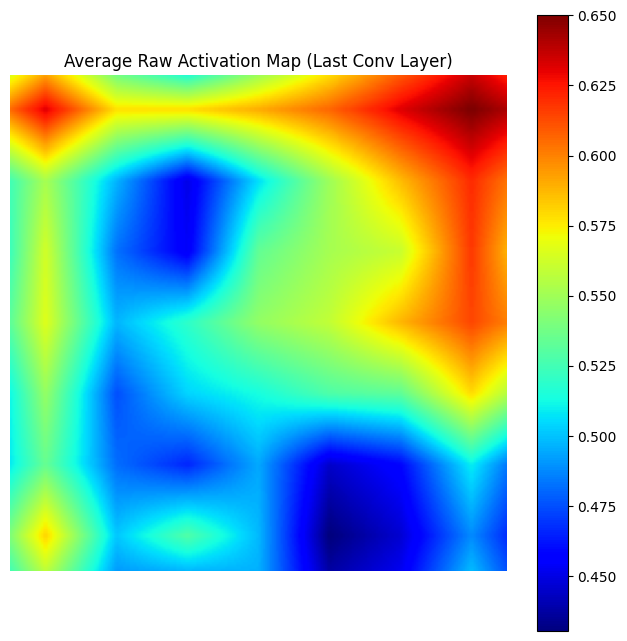

In [23]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# Raw activations (simple baseline explanation):
# Take last conv feature maps, average across channels, upsample to image size.

def _to_display_rgb(pil_img):
    arr = np.asarray(pil_img)
    if arr.ndim == 2:
        arr = np.stack([arr, arr, arr], axis=-1)
    if arr.shape[-1] == 4:
        arr = arr[..., :3]
    return arr


def visualize_raw_activations(model, input_tensor, pil_image=None, layer_name=None):
    """Visualize mean raw activation map from last conv layer.

    - model: torch.nn.Module (eval)
    - input_tensor: (1,3,H,W) normalized input
    - pil_image: optional PIL image for overlay
    - layer_name: optional explicit module name from model.named_modules()
    """

    device = next(model.parameters()).device
    x = input_tensor.to(device)

    captured = {}

    def hook_fn(_m, _inp, out):
        captured['feat'] = out

    # pick layer
    target = None
    target_name = None
    if layer_name is not None:
        for n, m in model.named_modules():
            if n == layer_name:
                target = m
                target_name = n
                break
        if target is None:
            print(f"Layer '{layer_name}' not found. Falling back to last Conv2d.")

    if target is None:
        for n, m in model.named_modules():
            if isinstance(m, torch.nn.Conv2d):
                target = m
                target_name = n
        if target is None:
            raise RuntimeError('No Conv2d layers found in model')

    h = target.register_forward_hook(hook_fn)
    try:
        with torch.no_grad():
            _ = model(x)
    finally:
        h.remove()

    feat = captured.get('feat')
    if feat is None:
        raise RuntimeError('Activation hook did not capture features')

    # feat: (1,C,h,w)
    act = feat[0].mean(dim=0, keepdim=True).unsqueeze(0)  # (1,1,h,w)
    act = F.relu(act)
    act = F.interpolate(act, size=(x.shape[-2], x.shape[-1]), mode='bilinear', align_corners=False)
    act = act[0, 0]
    act = (act - act.min()) / (act.max() - act.min() + 1e-8)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    if pil_image is not None:
        plt.imshow(_to_display_rgb(pil_image))
    else:
        # fallback: show normalized tensor (not ideal but safe)
        img = x[0].detach().cpu()
        img = img.permute(1, 2, 0).numpy()
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        plt.imshow(img)
    plt.title('Input')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    if pil_image is not None:
        plt.imshow(_to_display_rgb(pil_image))
        plt.imshow(act.detach().cpu().numpy(), cmap='jet', alpha=0.45)
        plt.title(f'Raw activation overlay\n(layer={target_name})')
    else:
        plt.imshow(act.detach().cpu().numpy(), cmap='jet')
        plt.title(f'Raw activation map\n(layer={target_name})')
    plt.axis('off')

    plt.tight_layout()
    plt.show()


# Uses variables created earlier in the notebook:
# - model (loaded checkpoint)
# - input_tensor (preprocessed, shape 1x3x224x224)
# - img_vis (PIL image)
visualize_raw_activations(model, input_tensor, pil_image=globals().get('img_vis', None))


### Sharpness Statistics (Hessian curvature) + “Sharpness Loss” (SAM-style)

To make “sharpness awareness” measurable (not just training cross-entropy), we compute two things on a **single minibatch**:

- **SAM sharpness loss proxy**: compute loss at current weights \(w\) and at a SAM-perturbed point \(w + \epsilon\) (\(\epsilon\) built from the batch gradient, radius \(\rho\)). We report \(\Delta = L(w+\epsilon) - L(w)\). Bigger \(\Delta\) ⇒ locally sharper region.
- **PyHessian curvature stats**: estimate top Hessian eigenvalue(s) and trace (batch-wise). Larger values ⇒ sharper curvature.

These use a minibatch (so not fully “dataset-free”), but they directly quantify **curvature around the solution**, which is what your professor was asking for.

In [24]:
# Install PyHessian (curvature / sharpness stats)
!pip -q install pyhessian
print('pyhessian installed')


In [33]:
import torch
import torch.nn as nn
from pyhessian import hessian

# Compute sharpness metrics on ONE minibatch (fast, report-friendly)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.eval()

criterion = nn.CrossEntropyLoss()

# Get a real minibatch from our dataloader (keeps class mapping + transforms consistent)
from dataset import build_dataloaders

train_loader, val_loader, test_loader = build_dataloaders(batch_size=16, num_workers=2)

x_batch, y_batch = next(iter(val_loader))
x_batch = x_batch.to(device)
y_batch = y_batch.to(device)

print('batch:', tuple(x_batch.shape), tuple(y_batch.shape), 'device:', device)

# 1) SAM “sharpness loss” proxy: Δ = L(w+ε) - L(w)
# ε uses SAM first-step perturbation with radius rho.

def sam_sharpness_delta(model, x, y, rho=0.05):
    model.zero_grad(set_to_none=True)
    logits = model(x)
    loss = criterion(logits, y)

    params = [p for p in model.parameters() if p.requires_grad]
    grads = torch.autograd.grad(loss, params, create_graph=False)

    grad_norm = torch.norm(torch.stack([g.norm(p=2) for g in grads if g is not None]), p=2)
    scale = rho / (grad_norm + 1e-12)

    # save + perturb
    old = [p.data.clone() for p in params]
    with torch.no_grad():
        for p, g in zip(params, grads):
            p.add_(scale * g)

    with torch.no_grad():
        loss_pert = criterion(model(x), y)

    # restore
    with torch.no_grad():
        for p, o in zip(params, old):
            p.data.copy_(o)

    return float(loss.detach().cpu()), float(loss_pert.detach().cpu()), float((loss_pert - loss).detach().cpu()), float(grad_norm.detach().cpu())

base_loss, pert_loss, delta, gnorm = sam_sharpness_delta(model, x_batch, y_batch, rho=0.05)
print('SAM sharpness proxy (rho=0.05)')
print(f'  loss(w)     : {base_loss:.6f}')
print(f'  loss(w+eps) : {pert_loss:.6f}')
print(f'  delta       : {delta:.6f}')
print(f'  grad_norm   : {gnorm:.6f}')

# 2) PyHessian curvature statistics
# Keep it minimal & stable: top eigenvalue estimate + trace estimate.

class SingleBatchLoader:
    def __init__(self, x, y):
        self._x = x.detach().cpu()
        self._y = y.detach().cpu()
        self.dataset = [0]
    def __iter__(self):
        yield self._x, self._y
    def __len__(self):
        return 1

sb = SingleBatchLoader(x_batch, y_batch)
H = hessian(model, criterion, dataloader=sb, cuda=torch.cuda.is_available())

# Top eigenvalue (approx)
try:
    top_eigs, _ = H.eigenvalues(top_n=1)
    print('Top Hessian eigenvalue (approx):', float(top_eigs[0]))
except Exception as e:
    print('H.eigenvalues failed:', repr(e))

# Trace estimate
try:
    tr = H.trace()
    if isinstance(tr, (list, tuple)) and len(tr) > 0:
        tr_val = float(sum(tr) / len(tr))
    else:
        tr_val = float(tr)
    print('Hessian trace estimate:', tr_val)
except Exception as e:
    print('H.trace failed:', repr(e))

print('Done.')


Trace of Hessian: [615327936.0, 297880.0, 285197152.0, 100303864.0, 89727704.0, 1711980544.0, 37760848.0, 769655104.0, 747179072.0, 25828356.0, 19139104.0, 1287560960.0, 2489189376.0, 3203001856.0, 255412064.0, 14490352.0, 411762880.0, 13415930.0, 124095616.0, -10313498.0, 213944448.0, 853139200.0, 34310056.0, -4629020.0, 813223488.0, 1045879104.0, 236326160.0, 2957722880.0, 205117056.0, 147481056.0, 2058235904.0, 71386368.0, 1354246400.0, 3516642304.0, 195990848.0, 102958840.0, -16634835.0, 674784000.0, 120319056.0, 1547797248.0, 214002016.0, 956148608.0, -15459643.0, 96532384.0, 701479360.0]


AttributeError: 'hessian' object has no attribute 'hessian_vector_product'